<a href="https://colab.research.google.com/github/aoibhinmwalsh/MSc_Project_Renewable_Energy_Forecasting/blob/main/MSc_Project_AW_Notebook_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Created a new notebook (made a copy) after saving the model weights after cv training and hyperparameter tuning.
This was so I didn't have to keep running it again each time.
Similar set up to the original notebook, but takes out the data preparation, cv training and hyperparameter tuning.
Used this notebook to complete all training and test evaluations, visualisation through plots etc.


## Renewable Energy Forecasting - HadUK and NESO Datasets

In [160]:
# mounting google drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Reading in Datasets

In [161]:
#need this library to read in nc files from met office
!pip install xarray netCDF4

In [162]:
import xarray as xr
import pandas as pd
import numpy as np
import seaborn as sns

##LSTM

Model Configuration

In [163]:
#PyTorch and neural network libraries
import torch
import torch.nn as nn

In [164]:
#LSTM
#takes a sequence of previous time steps and predicts the next value
#i.e. next months wind, solar or hydro energy output

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.2):
        super().__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True) #batch first so its shaped batch_size, sequence_lenth, features rather than default s, b, f
        self.dropout = nn.Dropout(dropout) #dropout to prevent overfitting
        self.fc = nn.Linear(hidden_size, 1) #last layer than maps the LSTM hidden state to single value
                                            #this value is the renewable energy output
    #forward pass
    def forward(self, x):
        out, ignore = self.rnn(x) #ignoring the hidden state and cell state as we dont need this detail just want output
        last_hidden = self.dropout(out[:, -1, :]) #getting the last steps output
        return self.fc(last_hidden) #mapping that vector to the predicted value

##GRU

Model Configuration

In [165]:
#GRU
#almost identical to LSTM but less trainable parameters and only one update gate rather than multiple
#takes a sequence of previous time steps and predicts the next value
#i.e. next months wind, solar or hydro energy output

class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.2):
        super().__init__()
        self.rnn = nn.GRU(input_size, hidden_size, num_layers, batch_first=True) #batch first so its shaped batch_size, sequence_lenth, features rather than default s, b, f
        self.dropout = nn.Dropout(dropout) #dropout to prevent overfitting
        self.fc = nn.Linear(hidden_size, 1) #last layer than maps the GRU hidden state to single value
                                            #this value is the renewable energy output

    #forward pass
    def forward(self, x):
        out, ignore = self.rnn(x) #ignoring the hidden state and cell state as we dont need this detail just want output
        last_hidden = self.dropout(out[:, -1, :]) #getting the last steps output
        return self.fc(last_hidden) #mapping that vector to the predicted value

##LSTMx

Model COnfiguration

In [166]:
#xLSTM is not built into PyTorch like LSTM and GRU
#installing the xLSTM package
!pip install xlstm

In [167]:
from xlstm import xLSTMBlockStack, xLSTMBlockStackConfig, mLSTMBlockConfig, sLSTMBlockConfig
#importing nn module (block stack), configuration package, mLSTM config for matrix memory and sLSTM config for scalar memory

class XLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.2, window_size=6):
        super().__init__()
        #configuration for xLSTM
        #mLSTM, sLSTM, no. of blocks/layers and expected sequence sizes
        config = xLSTMBlockStackConfig(
            mlstm_block=mLSTMBlockConfig(),
            slstm_block=sLSTMBlockConfig(),
            num_blocks=num_layers, #blocks/layers
            embedding_dim=hidden_size,
            context_length=window_size, #window size as in the sequence func from earlier
            slstm_at=[],) #have to specify which block positions to use slSTM, dont want any, just want mLSTM
        #xLSTM needs projected embedding_dim whereas GRU/LSTM can have raw input size
        #this layer creates that projection
        self.input_proj = nn.Linear(input_size, hidden_size)
        self.xlstm = xLSTMBlockStack(config) #actual xLSTM layer
        self.dropout = nn.Dropout(dropout) #drop out to avoid over fitting
        self.fc = nn.Linear(hidden_size, 1) #maps hidden to single predicted value, which again is the predicted energy generation

    #forward pass
    def forward(self, x):
        x = self.input_proj(x) #project raw input to embedding dimensions
        out = self.xlstm(x) #putting projected input through xLSTM
        last_hidden = self.dropout(out[:, -1, :]) #taking last time step
        return self.fc(last_hidden) #mapping that last time step to predicted value

In [168]:
#training and evaluation function
#trains on the specified archictecture (LSTM/GRU/xLSTM) across the cross validation folds
#returns average validation performance

#has early stopping so stops if val loss isn't improved between epochs
#records best val val loss for that fold

def train_and_evaluate(model_class, config, window_size, cv_folds, epochs=50, patience=10, seed=42):
    fold_val_losses = []

    #learning rate needs to separate parameter from configuration as it needs to be used in a different part
    model_config = {k: v for k, v in config.items() if k != 'learning_rate'}
    lr = config.get('learning_rate', 0.001)

    #train and validating once per cv fold
    for X_tr, X_val, y_tr, y_val in cv_folds:

        #converting into windowed sequences for the RNN's LSTM/GRU/xLSTM
        X_tr_seq, y_tr_seq = sequence(X_tr, y_tr, window_size)
        X_val_seq, y_val_seq = sequence(X_val, y_val, window_size)

        #convert arrays into PyTorch tensors
        X_tr_t = torch.tensor(X_tr_seq, dtype=torch.float32)
        y_tr_t = torch.tensor(y_tr_seq, dtype=torch.float32)
        X_val_t = torch.tensor(X_val_seq, dtype=torch.float32)
        y_val_t = torch.tensor(y_val_seq, dtype=torch.float32)


        #fixing a random seed so results are reporoducible and consistent across models and folds
        #same inital weights
        torch.manual_seed(seed)
        np.random.seed(seed)


        #structure for xLSTM is slightly different and need to include window size
        #for LSTM and GRU the weights wont change depending on the sequence length, it only needs to know the sequence
        #because of matrix memory, xLSTM needs the max sequence length (window size) at the beginning

        if model_class == XLSTMModel:
            model = model_class(input_size=X_tr_t.shape[2], window_size=window_size, **model_config)
        else:
            model = model_class(input_size=X_tr_t.shape[2], **model_config)

        #adam optimiser, updates model parameters scaled by the lr
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        #loss function mean squared error
        loss_fn = nn.MSELoss()

        #best/lowest validation loss in current fold
        best_val_loss = float('inf')
        epochs_no_improve = 0

        for epoch in range(epochs):
            #training
            model.train()
            optimizer.zero_grad() #clearing gradient from previous epoch
            preds = model(X_tr_t) #forward pass of the selected model
            loss = loss_fn(preds, y_tr_t) #comparing predictions and real observed values
            loss.backward() #computing gradients of the loss
            optimizer.step() #updates model weights using those gradients


            #validation
            model.eval() #switches of training mode
            with torch.no_grad(): #dont need the gradients for this part of evaluation
                val_preds = model(X_val_t)
                val_loss = loss_fn(val_preds, y_val_t).item() #calculating loss and converting to float rather than tensor

            if val_loss < best_val_loss: #if loss is improved
                best_val_loss = val_loss #update the best loss
                epochs_no_improve = 0 #reset this count to 0
            else:
                epochs_no_improve += 1 #if not increase this count by 1
                if epochs_no_improve >= patience:
                    break #if it hasn't improved for patience (10) epochs, move on to the next fold

        fold_val_losses.append(best_val_loss) #record the best result from thaat cv fold

    return np.mean(fold_val_losses), np.std(fold_val_losses) #returning avergae loss across the folds and the std
    #to see how consisitent it is across folds

In [169]:
clean_df = pd.read_csv('/content/drive/MyDrive/clean_df.csv')

##Hyper Parameter Tuning

Window Size

In [170]:
#data preparation func
#pepares data for training
#cleans, splits chronologically, scales and creates the cross validations folds
def data_prep(df, target, feature_cols, n_splits, test_size):

  #dropping any empty rows, there shouldn't be any with this data but just incase
  df = df[feature_cols + [target]].dropna()

  # Removing time column, not numeric and cant be scaled
  if 'time' in feature_cols:
      feature_cols.remove('time')
  if 'time' in df.columns:
      df = df.drop(columns=['time'])

  #splitting data in chronological order without shuffling - to prevent data leakage (would be able to look at future values w/ shuffle)
  split_idx = int(len(df) * (1 - test_size))
  train_data = df.iloc[:split_idx]
  test_data = df.iloc[split_idx:]

  #scaling data - needed for LSTM, xLSTM and GRU
  #sensitive to scale
  scaler_X = MinMaxScaler()
  scaler_y = MinMaxScaler()

  #scaling feature and target separately
  X_train = scaler_X.fit_transform(train_data[feature_cols])
  y_train = scaler_y.fit_transform(train_data[[target]])

  #only transform test data don't fit to prevent data leakage
  X_test = scaler_X.transform(test_data[feature_cols])
  y_test = scaler_y.transform(test_data[[target]])

  #cv folds need to be chronological, standard cv would shuffle
  ts_cross_val = TimeSeriesSplit(n_splits=n_splits)

  cv_folds = []

  for train_idx, val_idx in ts_cross_val.split(X_train):
    X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]
    cv_folds.append((X_train_fold, X_val_fold, y_train_fold, y_val_fold))

  return cv_folds, X_test, y_test, scaler_X, scaler_y
  #returnig scalars as well as cv and test sets so I can use them later to transform back when needed in analysis

In [171]:
#establishing target features for each renewable source
#they're all going to be done separetly on each of the 3 architectures
wind_target = clean_df['WIND']
wind_features = clean_df.drop(columns=['WIND'])

solar_target = clean_df['SOLAR']
solar_features = clean_df.drop(columns=['SOLAR'])

hydro_target = clean_df['HYDRO']
hydro_features = clean_df.drop(columns=['HYDRO'])

In [172]:
#needs to be split chronologically not randoml as its time series
from sklearn.model_selection import TimeSeriesSplit

In [173]:
#importing minmax scalar
#all of these models are really sensitive to scale
from sklearn.preprocessing import MinMaxScaler

In [174]:
#dropped time from predtictive features, can't scaled as touched on earlier
#included orignal weather variables, lags, cyclical, range and incr sequence
pred_features = ['tas', 'sfcWind', 'sun', 'rainfall', 'month_sin', 'month_cos', 'tas_lag', 'rainfall_lag',
       'sun_lag', 'sfcWind_lag', 'tasmin_lag', 'tasmax_lag', 'incr_seq',
       'temp_range']

#wind
wind_cv_folds, wind_X_test, wind_y_test, wind_scaler_X, wind_scaler_y = data_prep(clean_df, 'WIND', pred_features, 3, 0.2)

#solar
#first few years have solar as 0, assuming capacity was low or no sunshine, just deleting entries where solar is 0 - only for the solar one though the others
# stay the same (wind, hydro)
#very limited data as it is
solar_non_zero_start = clean_df[clean_df['SOLAR'] > 0].index.min()
solar_df = clean_df.loc[solar_non_zero_start:]
solar_cv_folds, solar_X_test, solar_y_test, solar_scaler_X, solar_scaler_y = data_prep(solar_df, 'SOLAR', pred_features, 3, 0.2)

#hydro
hydro_cv_folds, hydro_X_test, hydro_y_test, hydro_scaler_X, hydro_scaler_y = data_prep(clean_df, 'HYDRO', pred_features, 3, 0.2)


#proceeding with clean_df for hydro and wind, then solar_df for solar

In [175]:
#converts feature and target into overlapping sequences using
#a specified window size
#uses the past [selected window size] observations to predict the next value
def sequence(X, y, window_size):
    X_seq, y_seq = [], [] #empty array
    for i in range(len(X) - window_size): #going one time (month) step across each time
        X_seq.append(X[i : i + window_size]) #taking window size number of entries as the sequence
        y_seq.append(y[i + window_size]) #target is the value just after the window
    return np.array(X_seq), np.array(y_seq)

In [176]:
practice_config = {'hidden_size': 32, 'num_layers': 1, 'dropout': 0.2, 'learning_rate': 0.001}

#seeing how they go with random configs to see how they compare
#onlydoing 1 layer because there is really limited data
mean_loss, std_loss = train_and_evaluate(LSTMModel, practice_config, window_size=6, cv_folds=wind_cv_folds)
print(LSTMModel, mean_loss, std_loss)

mean_loss, std_loss = train_and_evaluate(GRUModel, practice_config, window_size=6, cv_folds=wind_cv_folds)
print(GRUModel, mean_loss, std_loss)

mean_loss, std_loss = train_and_evaluate(XLSTMModel, practice_config, window_size=6, cv_folds=wind_cv_folds)
print(XLSTMModel, mean_loss, std_loss)

<class '__main__.LSTMModel'> 0.04916738967100779 0.03611652272321455
<class '__main__.GRUModel'> 0.037043810822069645 0.036613644968159914
<class '__main__.XLSTMModel'> 0.021840889006853104 0.010016833356498365


Ran all of the window hyperparameter tuning on this notebook again because I forgot to run the hydro and solar ones on the other notebook, didn't want to rerun the whole session on the previous notebook

In [177]:
#hyperparameter tuning for window size, might have to go smaller bc sample sizes are really small
window_sizes = [3, 6, 9, 12]

def tune_window_size(model_class, config, window_sizes, cv_folds, epochs=50, patience=10):
    results = []
    for ws in window_sizes:
      #training and evaluating at current window size in the for loop
      #other configurations stay the same
        mean_loss, std_loss = train_and_evaluate(model_class, config, window_size=ws, cv_folds=cv_folds,
            epochs=epochs, patience=patience)
        results.append({'window_size': ws, 'mean_val_loss': mean_loss, 'std_val_loss': std_loss}) #adding window size and results to list
        print(model_class.__name__, ws, mean_loss, std_loss) #printing the model name
    return pd.DataFrame(results) #converting to df

tune_window_size(LSTMModel, practice_config, window_sizes, wind_cv_folds)

tune_window_size(GRUModel, practice_config, window_sizes, wind_cv_folds)

tune_window_size(XLSTMModel, practice_config, window_sizes, wind_cv_folds)

LSTMModel 3 0.0541007307668527 0.04083303062686878
LSTMModel 6 0.04916738967100779 0.03611652272321455
LSTMModel 9 0.04660907139380773 0.033806890456156743
LSTMModel 12 0.04940079525113106 0.03639414065336316
GRUModel 3 0.04343234654515982 0.04318304024637271
GRUModel 6 0.037043810822069645 0.036613644968159914
GRUModel 9 0.03663833004732927 0.035240113282083776
GRUModel 12 0.04039033486818274 0.03896089817666764
XLSTMModel 3 0.04228390008211136 0.027473653435946155
XLSTMModel 6 0.021840889006853104 0.010016833356498365
XLSTMModel 9 0.02693194771806399 0.01622251968226115
XLSTMModel 12 0.04508823901414871 0.02754256424590676


,window_size,mean_val_loss,std_val_loss
0,3,0.042284,0.027474
1,6,0.021841,0.010017
2,9,0.026932,0.016223
3,12,0.045088,0.027543


In [178]:
tune_window_size(LSTMModel, practice_config, window_sizes, solar_cv_folds)

tune_window_size(GRUModel, practice_config, window_sizes, solar_cv_folds)

tune_window_size(XLSTMModel, practice_config, window_sizes, solar_cv_folds)

LSTMModel 3 0.07177253315846126 0.004671543315524996
LSTMModel 6 0.07113866259654363 0.005959802001411219
LSTMModel 9 0.07002184664209683 0.01307669713265965
LSTMModel 12 0.06786905725797017 0.010025311371114584
GRUModel 3 0.04191528478016456 0.0394019774547874
GRUModel 6 0.03988003761818012 0.04214210330235578
GRUModel 9 0.040380857729663454 0.04746491349692291
GRUModel 12 0.01911629301806291 0.01661733226927878
XLSTMModel 3 0.032639805848399796 0.008625510921925263
XLSTMModel 6 0.022835527701924246 0.019519997476386393
XLSTMModel 9 0.01132678147405386 0.006364626274563355
XLSTMModel 12 0.016902958353360493 0.004844425809765068


,window_size,mean_val_loss,std_val_loss
0,3,0.032640,0.008626
1,6,0.022836,0.019520
2,9,0.011327,0.006365
3,12,0.016903,0.004844


In [179]:
tune_window_size(LSTMModel, practice_config, window_sizes, hydro_cv_folds)

tune_window_size(GRUModel, practice_config, window_sizes, hydro_cv_folds)

tune_window_size(XLSTMModel, practice_config, window_sizes, hydro_cv_folds)

LSTMModel 3 0.05653617282708486 0.009770978277282053
LSTMModel 6 0.05694297328591347 0.008014642678744615
LSTMModel 9 0.059379562735557556 0.003259859185790084
LSTMModel 12 0.06041644886136055 0.0067474630562957385
GRUModel 3 0.02795954669515292 0.00595009017541289
GRUModel 6 0.02761162507037322 0.004696237434217001
GRUModel 9 0.02722193921605746 0.005242873129630681
GRUModel 12 0.026577260345220566 0.004108177789765236
XLSTMModel 3 0.03560150476793448 0.004367949309138659
XLSTMModel 6 0.03467772901058197 0.0012351331523170704
XLSTMModel 9 0.031791760896643005 0.0028301229454247047
XLSTMModel 12 0.036268915981054306 0.0026145122766690443


,window_size,mean_val_loss,std_val_loss
0,3,0.035602,0.004368
1,6,0.034678,0.001235
2,9,0.031792,0.002830
3,12,0.036269,0.002615


some 9 months is best and some 6 months is best, went with all at 6 for fair comparison

In [180]:
import itertools
import pandas as pd

#different praramters the grid search will loop over and test out
param_grid = {'hidden_size': [16, 32, 64], 'num_layers': [1, 2], 'dropout': [0.1, 0.2, 0.3], 'learning_rate': [0.01, 0.001, 0.0005],}

#grid search will do the train_and_evaluate for every combination of parameters
#want to see which is best for each model architecture
def grid_search(model_class, param_grid, window_size, cv_folds, epochs=50, patience=10, seed=42):
    keys = list(param_grid.keys()) #keeps parameter name order
    results = []

    for values in itertools.product(*param_grid.values()): #generates cartesian product of all values in paramter list, so every combination
        config = dict(zip(keys, values)) #pairs values back with their parameter name
        mean_loss, std_loss = train_and_evaluate(model_class, config, window_size, cv_folds,
        epochs=epochs, patience=patience, seed=seed) #running it through training and evluation to calc cv loss stats
        results.append({**config, 'mean_val_loss': mean_loss, 'std_val_loss': std_loss}) #add it to the list
        print(config, mean_loss, std_loss) #print the results

    return pd.DataFrame(results).sort_values('mean_val_loss').reset_index(drop=True) #returning all the results as a dataframe
    #data frame is sorted to ascending, so best performing config will be the first entry

In [181]:
len(clean_df)

192

#Evaluation on Full Train and Test sets

In [182]:
#constructing the full training set thats needed from the cross validation folds
def get_train_full(cv_folds):
    X_tr_last, X_val_last, y_tr_last, y_val_last = cv_folds[-1] #getting the last cv fold
    X_train_full = np.concatenate([X_tr_last, X_val_last], axis=0) #putting X together - features
    y_train_full = np.concatenate([y_tr_last, y_val_last], axis=0) #putting y together - target
    return X_train_full, y_train_full

In [183]:
model = LSTMModel(input_size=14, hidden_size=16, num_layers=1, dropout=0.1)
model.load_state_dict(torch.load('/content/drive/MyDrive/WIND_LSTMModel.pth'))
model.eval()

LSTMModel(
  (rnn): LSTM(14, 16, batch_first=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=16, out_features=1, bias=True)
)

In [184]:
#loading in saved weights for each of the best performing wind models for each RNN arch
wind_lstm = LSTMModel(input_size=14, hidden_size=16, num_layers=1, dropout=0.1)
wind_lstm.load_state_dict(torch.load('/content/drive/MyDrive/WIND_LSTMModel.pth'))
wind_lstm.eval()

wind_gru = GRUModel(input_size=14, hidden_size=32, num_layers=2, dropout=0.3)
wind_gru.load_state_dict(torch.load('/content/drive/MyDrive/WIND_GRUModel.pth'))
wind_gru.eval()

wind_xlstm = XLSTMModel(input_size=14, window_size=6, hidden_size=64, num_layers=1, dropout=0.1)
wind_xlstm.load_state_dict(torch.load('/content/drive/MyDrive/WIND_XLSTMModel.pth'))
wind_xlstm.eval()

XLSTMModel(
  (input_proj): Linear(in_features=14, out_features=64, bias=True)
  (xlstm): xLSTMBlockStack(
    (blocks): ModuleList(
      (0): mLSTMBlock(
        (xlstm_norm): LayerNorm()
        (xlstm): mLSTMLayer(
          (proj_up): Linear(in_features=64, out_features=256, bias=False)
          (q_proj): LinearHeadwiseExpand(in_features=128, num_heads=32, expand_factor_up=1, bias=False, trainable_weight=True, trainable_bias=True, )
          (k_proj): LinearHeadwiseExpand(in_features=128, num_heads=32, expand_factor_up=1, bias=False, trainable_weight=True, trainable_bias=True, )
          (v_proj): LinearHeadwiseExpand(in_features=128, num_heads=32, expand_factor_up=1, bias=False, trainable_weight=True, trainable_bias=True, )
          (conv1d): CausalConv1d(
            (conv): Conv1d(128, 128, kernel_size=(4,), stride=(1,), padding=(3,), groups=128)
          )
          (conv_act_fn): SiLU()
          (mlstm_cell): mLSTMCell(
            (igate): Linear(in_features=384, out_f

In [185]:
#same for solar
solar_lstm = LSTMModel(input_size=14, hidden_size=64, num_layers=1, dropout=0.3)
solar_lstm.load_state_dict(torch.load('/content/drive/MyDrive/SOLAR_LSTMModel.pth'))
solar_lstm.eval()

solar_gru = GRUModel(input_size=14, hidden_size=16, num_layers=2, dropout=0.1)
solar_gru.load_state_dict(torch.load('/content/drive/MyDrive/SOLAR_GRUModel.pth'))
solar_gru.eval()

solar_xlstm = XLSTMModel(input_size=14, window_size=6, hidden_size=64, num_layers=1, dropout=0.1)
solar_xlstm.load_state_dict(torch.load('/content/drive/MyDrive/SOLAR_XLSTMModel.pth'))
solar_xlstm.eval()

XLSTMModel(
  (input_proj): Linear(in_features=14, out_features=64, bias=True)
  (xlstm): xLSTMBlockStack(
    (blocks): ModuleList(
      (0): mLSTMBlock(
        (xlstm_norm): LayerNorm()
        (xlstm): mLSTMLayer(
          (proj_up): Linear(in_features=64, out_features=256, bias=False)
          (q_proj): LinearHeadwiseExpand(in_features=128, num_heads=32, expand_factor_up=1, bias=False, trainable_weight=True, trainable_bias=True, )
          (k_proj): LinearHeadwiseExpand(in_features=128, num_heads=32, expand_factor_up=1, bias=False, trainable_weight=True, trainable_bias=True, )
          (v_proj): LinearHeadwiseExpand(in_features=128, num_heads=32, expand_factor_up=1, bias=False, trainable_weight=True, trainable_bias=True, )
          (conv1d): CausalConv1d(
            (conv): Conv1d(128, 128, kernel_size=(4,), stride=(1,), padding=(3,), groups=128)
          )
          (conv_act_fn): SiLU()
          (mlstm_cell): mLSTMCell(
            (igate): Linear(in_features=384, out_f

In [186]:
#same for hydro
hydro_lstm = LSTMModel(input_size=14, hidden_size=64, num_layers=1, dropout=0.3)
hydro_lstm.load_state_dict(torch.load('/content/drive/MyDrive/HYDRO_LSTMModel.pth'))
hydro_lstm.eval()

hydro_gru = GRUModel(input_size=14, hidden_size=16, num_layers=1, dropout=0.2)
hydro_gru.load_state_dict(torch.load('/content/drive/MyDrive/HYDRO_GRUModel.pth'))
hydro_gru.eval()

hydro_xlstm = XLSTMModel(input_size=14, window_size=6, hidden_size=16, num_layers=1, dropout=0.1)
hydro_xlstm.load_state_dict(torch.load('/content/drive/MyDrive/HYDRO_XLSTMModel.pth'))
hydro_xlstm.eval()

XLSTMModel(
  (input_proj): Linear(in_features=14, out_features=16, bias=True)
  (xlstm): xLSTMBlockStack(
    (blocks): ModuleList(
      (0): mLSTMBlock(
        (xlstm_norm): LayerNorm()
        (xlstm): mLSTMLayer(
          (proj_up): Linear(in_features=16, out_features=128, bias=False)
          (q_proj): LinearHeadwiseExpand(in_features=64, num_heads=16, expand_factor_up=1, bias=False, trainable_weight=True, trainable_bias=True, )
          (k_proj): LinearHeadwiseExpand(in_features=64, num_heads=16, expand_factor_up=1, bias=False, trainable_weight=True, trainable_bias=True, )
          (v_proj): LinearHeadwiseExpand(in_features=64, num_heads=16, expand_factor_up=1, bias=False, trainable_weight=True, trainable_bias=True, )
          (conv1d): CausalConv1d(
            (conv): Conv1d(64, 64, kernel_size=(4,), stride=(1,), padding=(3,), groups=64)
          )
          (conv_act_fn): SiLU()
          (mlstm_cell): mLSTMCell(
            (igate): Linear(in_features=192, out_feature

In [187]:
#don't need all the training etc. all model weights are already established from previous notebook
#new scoring function
def score_model(model, X_test, y_test, window_size=6):
  #building sequences from test set
    X_test_seq, y_test_seq = sequence(X_test, y_test, window_size)
    X_test_t = torch.tensor(X_test_seq, dtype=torch.float32)

    #evaluation on test set
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_t).numpy()

    y_true = y_test_seq
    #regression metrics lined out in project aims using predicted v true values from test set
    return {'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred)}

In [188]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, mean_squared_error
all_results = []

#scoring each model and renewable energy source on the test set
#adding all results to the same df
all_results.append({**score_model(wind_lstm, wind_X_test, wind_y_test), 'dataset': 'WIND', 'model': 'LSTMModel'})
all_results.append({**score_model(wind_gru, wind_X_test, wind_y_test), 'dataset': 'WIND', 'model': 'GRUModel'})
all_results.append({**score_model(wind_xlstm, wind_X_test, wind_y_test), 'dataset': 'WIND', 'model': 'XLSTMModel'})

all_results.append({**score_model(solar_lstm, solar_X_test, solar_y_test), 'dataset': 'SOLAR', 'model': 'LSTMModel'})
all_results.append({**score_model(solar_gru, solar_X_test, solar_y_test), 'dataset': 'SOLAR', 'model': 'GRUModel'})
all_results.append({**score_model(solar_xlstm, solar_X_test, solar_y_test), 'dataset': 'SOLAR', 'model': 'XLSTMModel'})

all_results.append({**score_model(hydro_lstm, hydro_X_test, hydro_y_test), 'dataset': 'HYDRO', 'model': 'LSTMModel'})
all_results.append({**score_model(hydro_gru, hydro_X_test, hydro_y_test), 'dataset': 'HYDRO', 'model': 'GRUModel'})
all_results.append({**score_model(hydro_xlstm, hydro_X_test, hydro_y_test), 'dataset': 'HYDRO', 'model': 'XLSTMModel'})

results_df = pd.DataFrame(all_results)
results_df = results_df[['dataset', 'model', 'MAE', 'RMSE', 'R2', 'MAPE']]
results_df

,dataset,model,MAE,RMSE,R2,MAPE
0,WIND,LSTMModel,0.090788,0.111576,0.732476,0.142537
1,WIND,GRUModel,0.127155,0.150142,0.515578,0.201551
2,WIND,XLSTMModel,0.116731,0.139847,0.579731,0.161416
3,SOLAR,LSTMModel,0.140201,0.166564,0.735562,0.556465
4,SOLAR,GRUModel,0.137992,0.166418,0.736025,0.558298
5,SOLAR,XLSTMModel,0.087831,0.107835,0.889164,0.299701
6,HYDRO,LSTMModel,0.123162,0.149154,0.546711,2.441625
7,HYDRO,GRUModel,0.113368,0.139526,0.603342,1.979778
8,HYDRO,XLSTMModel,0.131025,0.165482,0.442035,2.143954


In [189]:
#clean_df.to_csv('/content/drive/MyDrive/clean_df.csv', index=False)

In [190]:
clean_df.isna().sum()

,0
time,0
tas,0
sfcWind,0
sun,0
rainfall,0
WIND,0
HYDRO,0
SOLAR,0
month_sin,0
month_cos,0


##Plots

In [191]:
#same as score model but want to return predictions rather than models
def get_predictions(model, X_test, y_test, window_size=6):
    X_test_seq, y_test_seq = sequence(X_test, y_test, window_size)
    X_test_t = torch.tensor(X_test_seq, dtype=torch.float32)

    #evaluating on test set
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_t).numpy()

    return y_test_seq, y_pred

In [192]:
import matplotlib.pyplot as plt

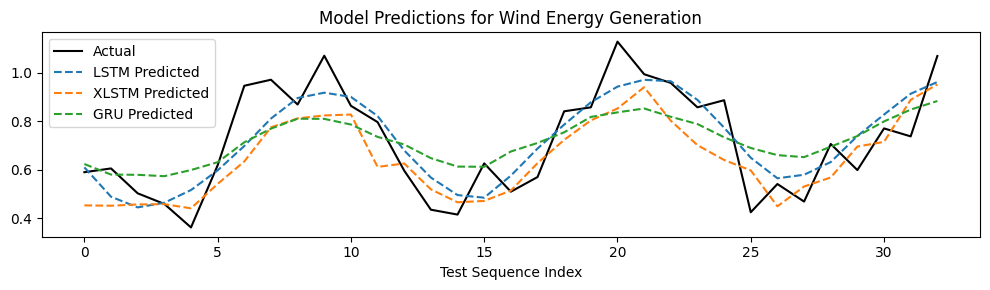

In [193]:
#getting true vs predicted values for wind across all three models
y_true_lstm, y_pred_lstm = get_predictions(wind_lstm, wind_X_test, wind_y_test)
y_true_xlstm, y_pred_xlstm = get_predictions(wind_xlstm, wind_X_test, wind_y_test)
y_true_gru, y_pred_gru = get_predictions(wind_gru, wind_X_test, wind_y_test)

plt.figure(figsize=(10, 3))
plt.plot(y_true_lstm, label='Actual', color='black', linewidth=1.5)
plt.plot(y_pred_lstm, label='LSTM Predicted', color='tab:blue', linestyle='--')
plt.plot(y_pred_xlstm, label='XLSTM Predicted', color='tab:orange', linestyle='--')
plt.plot(y_pred_gru, label='GRU Predicted', color='tab:green', linestyle='--')
plt.title('Model Predictions for Wind Energy Generation')
plt.legend()

plt.xlabel('Test Sequence Index')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/wind_pred_plot')
plt.show()

In [194]:
hydro_X_test.shape

(39, 14)

In [195]:
hydro_y_test.shape

(39, 1)

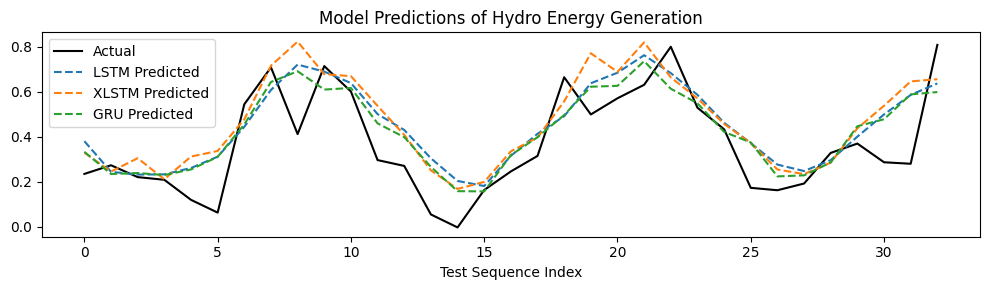

In [196]:
#getting true v predicted values for hydro across all 3 models
y_true_lstm, y_pred_lstm = get_predictions(hydro_lstm, hydro_X_test, hydro_y_test)
y_true_xlstm, y_pred_xlstm = get_predictions(hydro_xlstm, hydro_X_test, hydro_y_test)
y_true_gru, y_pred_gru = get_predictions(hydro_gru, hydro_X_test, hydro_y_test)

plt.figure(figsize=(10, 3))
plt.plot(y_true_lstm, label='Actual', color='black', linewidth=1.5)
plt.plot(y_pred_lstm, label='LSTM Predicted', color='tab:blue', linestyle='--')
plt.plot(y_pred_xlstm, label='XLSTM Predicted', color='tab:orange', linestyle='--')
plt.plot(y_pred_gru, label='GRU Predicted', color='tab:green', linestyle='--')
plt.title('Model Predictions of Hydro Energy Generation')
plt.legend()

plt.xlabel('Test Sequence Index')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/hydro_pred_plot')
plt.show()

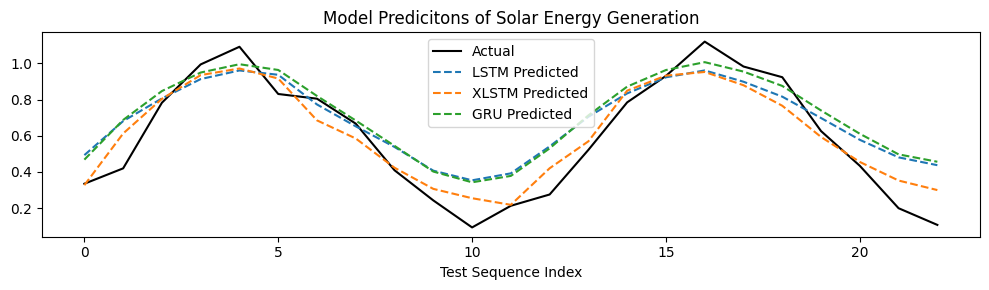

In [197]:
#getting true vs predicted values for solar across all three values
y_true_lstm, y_pred_lstm = get_predictions(solar_lstm, solar_X_test, solar_y_test)
y_true_xlstm, y_pred_xlstm = get_predictions(solar_xlstm, solar_X_test, solar_y_test)
y_true_gru, y_pred_gru = get_predictions(solar_gru, solar_X_test, solar_y_test)

plt.figure(figsize=(10, 3))
plt.plot(y_true_lstm, label='Actual', color='black', linewidth=1.5)
plt.plot(y_pred_lstm, label='LSTM Predicted', color='tab:blue', linestyle='--')
plt.plot(y_pred_xlstm, label='XLSTM Predicted', color='tab:orange', linestyle='--')
plt.plot(y_pred_gru, label='GRU Predicted', color='tab:green', linestyle='--')
plt.title('Model Predicitons of Solar Energy Generation')
plt.legend()

plt.xlabel('Test Sequence Index')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/solar_pred_plot')
plt.show()

In [198]:
clean_df.head()

,time,tas,sfcWind,sun,rainfall,WIND,HYDRO,SOLAR,month_sin,month_cos,tas_lag,rainfall_lag,sun_lag,sfcWind_lag,tasmin_lag,tasmax_lag,incr_seq,temp_range
0,2009-01-16,2.80764,5.125991,51.30176,119.21500,463.819220,545.055108,0.0,0.500000,8.660254e-01,NaN,NaN,NaN,NaN,NaN,NaN,0,5.74894
1,2009-02-16,3.68191,4.331586,51.34660,59.82887,336.264881,403.909970,0.0,0.866025,5.000000e-01,2.80764,119.21500,51.30176,5.125991,-0.05637,5.69257,1,5.47270
2,2009-03-16,6.07327,5.415443,137.01357,78.91117,513.778226,579.264113,0.0,1.000000,6.123234e-17,3.68191,59.82887,51.34660,4.331586,0.95441,6.42711,2,7.74856
3,2009-04-16,8.88506,4.338320,159.29671,60.00777,352.243056,387.883333,0.0,0.866025,-5.000000e-01,6.07327,78.91117,137.01357,5.415443,2.20411,9.95267,3,8.73973
4,2009-05-16,10.82159,5.289657,210.10925,81.70537,436.897849,308.916667,0.0,0.500000,-8.660254e-01,8.88506,60.00777,159.29671,4.338320,4.53813,13.27786,4,8.89638


In [199]:
len(clean_df)

192

In [200]:
clean_df.columns

Index(['time', 'tas', 'sfcWind', 'sun', 'rainfall', 'WIND', 'HYDRO', 'SOLAR',
       'month_sin', 'month_cos', 'tas_lag', 'rainfall_lag', 'sun_lag',
       'sfcWind_lag', 'tasmin_lag', 'tasmax_lag', 'incr_seq', 'temp_range'],
      dtype='object')

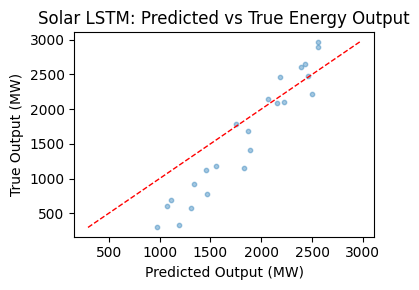

In [201]:
#getting predictions for solar lstm to plot pred vs true as scatter rather than over time
y_true, y_pred = get_predictions(solar_lstm, solar_X_test, solar_y_test, window_size=6)

#used the scalar saved from earlier to transform back into original scale from minmax scaling
y_true = solar_scaler_y.inverse_transform(y_true.reshape(-1, 1)).flatten()
y_pred = solar_scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()

plt.figure(figsize=(4, 3))
plt.scatter(y_pred, y_true, alpha=0.4, s=10)
#diagnonal line is perfect prediction
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', linewidth=1)
plt.title('Solar LSTM: Predicted vs True Energy Output')
plt.xlabel('Predicted Output (MW)')
plt.ylabel('True Output (MW)')
plt.tight_layout()
plt.show()

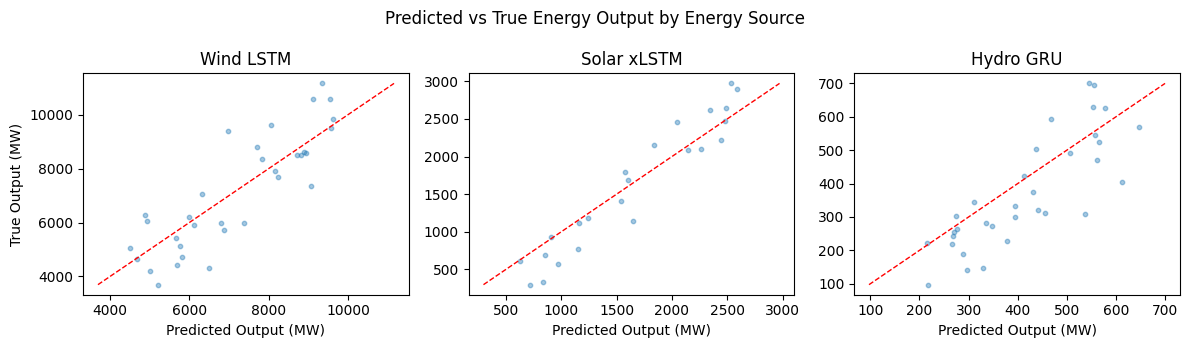

In [202]:
#wanted the best performing for each renewable resource on the same plot for the report side by side
#getting predictions for each one and transform back to original scale
wind_y_true, wind_y_pred = get_predictions(wind_lstm, wind_X_test, wind_y_test, window_size=6)
wind_y_true = wind_scaler_y.inverse_transform(wind_y_true.reshape(-1, 1)).flatten()
wind_y_pred = wind_scaler_y.inverse_transform(wind_y_pred.reshape(-1, 1)).flatten()

solar_y_true, solar_y_pred = get_predictions(solar_xlstm, solar_X_test, solar_y_test, window_size=6)
solar_y_true = solar_scaler_y.inverse_transform(solar_y_true.reshape(-1, 1)).flatten()
solar_y_pred = solar_scaler_y.inverse_transform(solar_y_pred.reshape(-1, 1)).flatten()

hydro_y_true, hydro_y_pred = get_predictions(hydro_gru, hydro_X_test, hydro_y_test, window_size=6)
hydro_y_true = hydro_scaler_y.inverse_transform(hydro_y_true.reshape(-1, 1)).flatten()
hydro_y_pred = hydro_scaler_y.inverse_transform(hydro_y_pred.reshape(-1, 1)).flatten()

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

#grouping them all together so I can do it in a for loop
data = [(wind_y_pred, wind_y_true, 'Wind LSTM'), (solar_y_pred, solar_y_true, 'Solar xLSTM'),
    (hydro_y_pred, hydro_y_true, 'Hydro GRU'),]
#one plot per arch/source of energy
for ax, (y_pred, y_true, label) in zip(axes, data):
    ax.scatter(y_pred, y_true, alpha=0.4, s=10)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())] #perfect prediciton line
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_title(label)
    ax.set_xlabel('Predicted Output (MW)')

axes[0].set_ylabel('True Output (MW)') #only put y label on far left
fig.suptitle('Predicted vs True Energy Output by Energy Source')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/pred_true_plot') #saving to google drive
plt.show()

##Residual Plots Wind POwer - LSTM, GRU and xLSTM

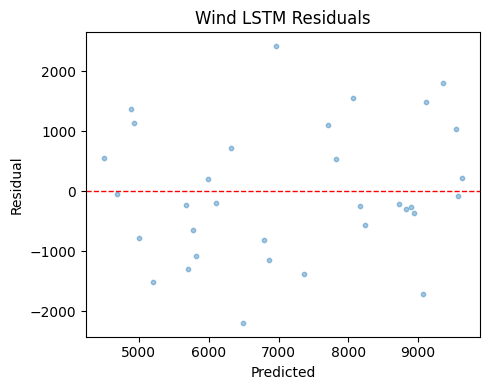

In [203]:
#residual plots for each best performing configuration
y_true, y_pred = get_predictions(wind_lstm, wind_X_test, wind_y_test, window_size=6)

#transforming back to original scale
y_true = wind_scaler_y.inverse_transform(y_true.reshape(-1, 1)).flatten()
y_pred = wind_scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()

#calc residual from prediction and actual values
residuals = y_true - y_pred

plt.figure(figsize=(5, 4))
plt.scatter(y_pred, residuals, alpha=0.4, s=10)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Wind LSTM Residuals')
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/res_wind_lstm') #saving to google drive
plt.show()

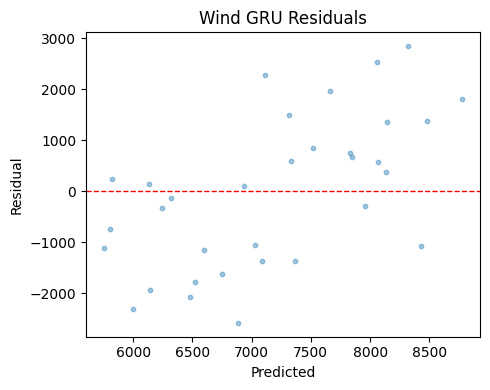

In [204]:
y_true, y_pred = get_predictions(wind_gru, wind_X_test, wind_y_test, window_size=6)

y_true = wind_scaler_y.inverse_transform(y_true.reshape(-1, 1)).flatten()
y_pred = wind_scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()

residuals = y_true - y_pred

plt.figure(figsize=(5, 4))
plt.scatter(y_pred, residuals, alpha=0.4, s=10)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Wind GRU Residuals')
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/res_wind_gru') #saving to google drive
plt.show()

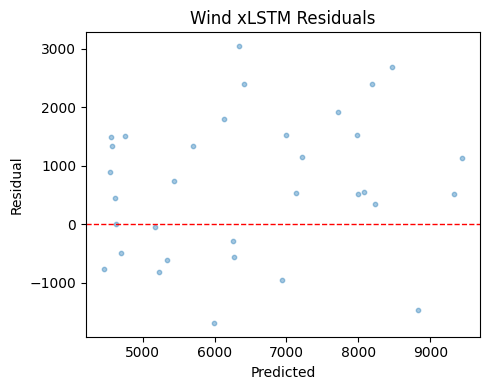

In [205]:
y_true, y_pred = get_predictions(wind_xlstm, wind_X_test, wind_y_test, window_size=6)

y_true = wind_scaler_y.inverse_transform(y_true.reshape(-1, 1)).flatten()
y_pred = wind_scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()

residuals = y_true - y_pred

plt.figure(figsize=(5, 4))
plt.scatter(y_pred, residuals, alpha=0.4, s=10)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Wind xLSTM Residuals')
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/res_wind_xlstm') #saving to google drive
plt.show()

##Hydro Residuals - LSTM, GRU and xLSTM

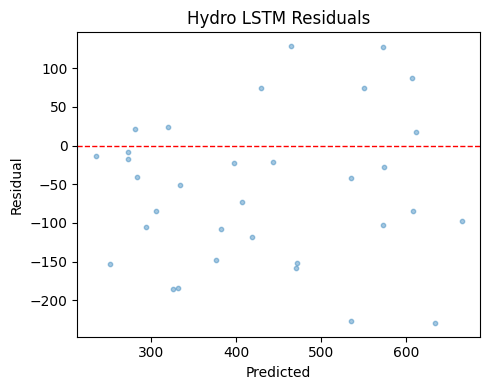

In [206]:
y_true, y_pred = get_predictions(hydro_lstm, hydro_X_test, hydro_y_test, window_size=6)

y_true = hydro_scaler_y.inverse_transform(y_true.reshape(-1, 1)).flatten()
y_pred = hydro_scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()

residuals = y_true - y_pred

plt.figure(figsize=(5, 4))
plt.scatter(y_pred, residuals, alpha=0.4, s=10)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Hydro LSTM Residuals')
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/res_hydro_lstm') #saving to google drive
plt.show()

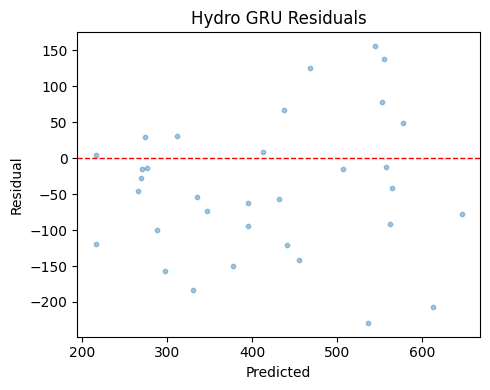

In [207]:
y_true, y_pred = get_predictions(hydro_gru, hydro_X_test, hydro_y_test, window_size=6)

y_true = hydro_scaler_y.inverse_transform(y_true.reshape(-1, 1)).flatten()
y_pred = hydro_scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()

residuals = y_true - y_pred

plt.figure(figsize=(5, 4))
plt.scatter(y_pred, residuals, alpha=0.4, s=10)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Hydro GRU Residuals')
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/res_hydro_gru') #saving to google drive
plt.show()

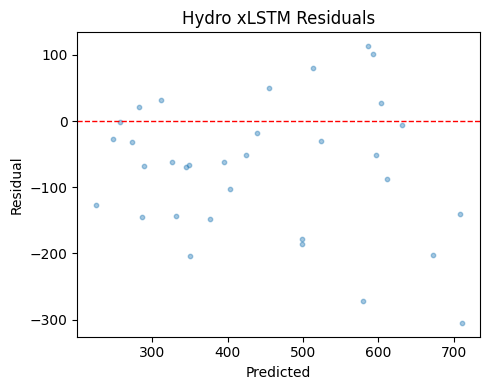

In [208]:
y_true, y_pred = get_predictions(hydro_xlstm, hydro_X_test, hydro_y_test, window_size=6)

y_true = hydro_scaler_y.inverse_transform(y_true.reshape(-1, 1)).flatten()
y_pred = hydro_scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()

residuals = y_true - y_pred

plt.figure(figsize=(5, 4))
plt.scatter(y_pred, residuals, alpha=0.4, s=10)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Hydro xLSTM Residuals')
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/res_hydro_xlstm') #saving to google drive
plt.show()

##Solar Residuals - LSTM, GRU and xLSTM

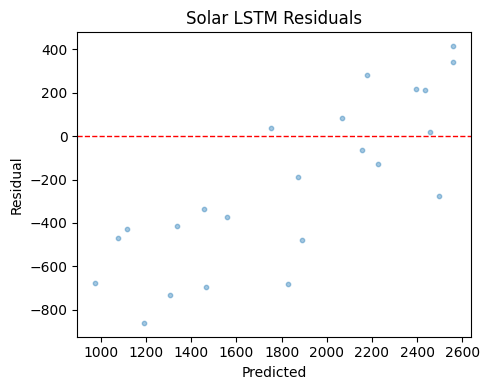

In [209]:
y_true, y_pred = get_predictions(solar_lstm, solar_X_test, solar_y_test, window_size=6)

y_true = solar_scaler_y.inverse_transform(y_true.reshape(-1, 1)).flatten()
y_pred = solar_scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()

residuals = y_true - y_pred

plt.figure(figsize=(5, 4))
plt.scatter(y_pred, residuals, alpha=0.4, s=10)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Solar LSTM Residuals')
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/res_solar_lstm') #saving to google drive
plt.show()

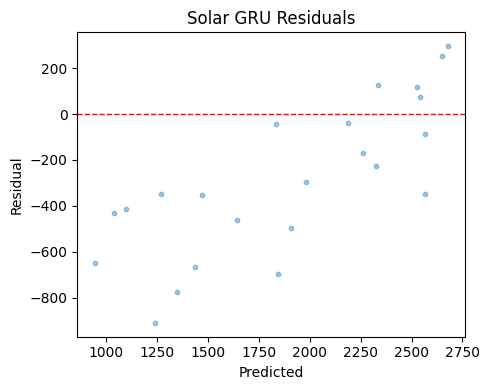

In [230]:
y_true, y_pred = get_predictions(solar_gru, solar_X_test, solar_y_test, window_size=6)

y_true = solar_scaler_y.inverse_transform(y_true.reshape(-1, 1)).flatten()
y_pred = solar_scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()

residuals = y_true - y_pred

plt.figure(figsize=(5, 4))
plt.scatter(y_pred, residuals, alpha=0.4, s=10)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Solar GRU Residuals')
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/res_solar_gru') #saving to google drive
plt.show()

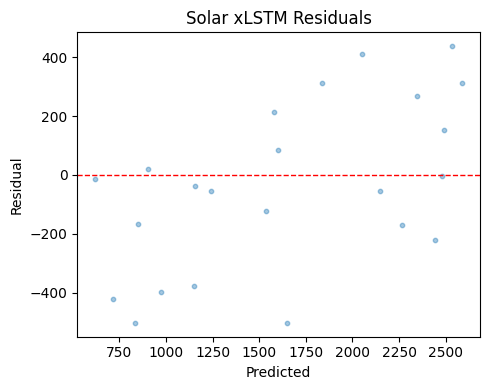

In [231]:
y_true, y_pred = get_predictions(solar_xlstm, solar_X_test, solar_y_test, window_size=6)

y_true = solar_scaler_y.inverse_transform(y_true.reshape(-1, 1)).flatten()
y_pred = solar_scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()

residuals = y_true - y_pred

plt.figure(figsize=(5, 4))
plt.scatter(y_pred, residuals, alpha=0.4, s=10)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Solar xLSTM Residuals')
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/res_solar_xlstm') #saving to google drive
plt.show()

Performance Metric Bar Plots

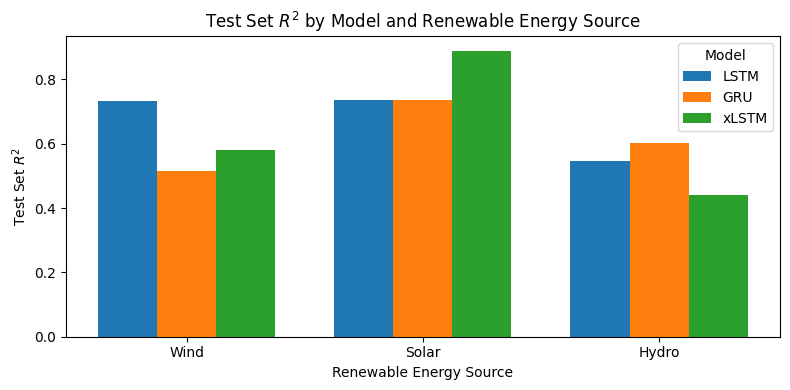

In [212]:
metric = 'R2' #want to plot the r2 metric, seems the most comparable across differing scales
datasets = results_df['dataset'].unique()
models = results_df['model'].unique()
x = np.arange(len(datasets)) #basing start on no of datsets - wind hydri solar
width = 0.25 #width of bar

#mapping names so not in all caps
model_labels = {'LSTMModel': 'LSTM', 'GRUModel': 'GRU', 'XLSTMModel': 'xLSTM'}
dataset_labels = {'WIND': 'Wind', 'SOLAR': 'Solar', 'HYDRO': 'Hydro'}

fig, ax = plt.subplots(figsize=(8, 4))
#getting r2 values for each renewable energy source in the right order
for i, model in enumerate(models):
    vals = [results_df[(results_df['dataset'] == d) & (results_df['model'] == model)][metric].values[0]
            for d in datasets]
      #plotting bars next to each increasing by width each time
    ax.bar(x + i * width, vals, width, label=model_labels.get(model, model))

ax.set_xticks(x + width) #tick labels at the centre
ax.set_xticklabels([dataset_labels.get(d, d) for d in datasets]) #converting to the non caps labels for plot
ax.set_ylabel('Test Set $R^2$')
ax.set_xlabel('Renewable Energy Source')
ax.set_title('Test Set $R^2$ by Model and Renewable Energy Source')
ax.legend(title='Model')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/r_square') #saving to google drive
plt.show()

In [213]:
clean_df.head(12)

,time,tas,sfcWind,sun,rainfall,WIND,HYDRO,SOLAR,month_sin,month_cos,tas_lag,rainfall_lag,sun_lag,sfcWind_lag,tasmin_lag,tasmax_lag,incr_seq,temp_range
0,2009-01-16,2.80764,5.125991,51.30176,119.21500,463.819220,545.055108,0.0,5.000000e-01,8.660254e-01,NaN,NaN,NaN,NaN,NaN,NaN,0,5.74894
1,2009-02-16,3.68191,4.331586,51.34660,59.82887,336.264881,403.909970,0.0,8.660254e-01,5.000000e-01,2.80764,119.21500,51.30176,5.125991,-0.05637,5.69257,1,5.47270
2,2009-03-16,6.07327,5.415443,137.01357,78.91117,513.778226,579.264113,0.0,1.000000e+00,6.123234e-17,3.68191,59.82887,51.34660,4.331586,0.95441,6.42711,2,7.74856
3,2009-04-16,8.88506,4.338320,159.29671,60.00777,352.243056,387.883333,0.0,8.660254e-01,-5.000000e-01,6.07327,78.91117,137.01357,5.415443,2.20411,9.95267,3,8.73973
4,2009-05-16,10.82159,5.289657,210.10925,81.70537,436.897849,308.916667,0.0,5.000000e-01,-8.660254e-01,8.88506,60.00777,159.29671,4.338320,4.53813,13.27786,4,8.89638
5,2009-06-16,13.65920,3.777869,202.93654,61.83162,186.378472,152.417361,0.0,1.224647e-16,-1.000000e+00,10.82159,81.70537,210.10925,5.289657,6.41803,15.31441,5,9.49349
6,2009-07-16,15.14549,4.401072,169.14627,145.39348,239.725806,167.327957,0.0,-5.000000e-01,-8.660254e-01,13.65920,61.83162,202.93654,3.777869,8.95686,18.45035,6,8.07884
7,2009-08-16,15.31254,4.757433,154.30047,114.39399,410.140457,370.229167,0.0,-8.660254e-01,-5.000000e-01,15.14549,145.39348,169.14627,4.401072,11.13392,19.21276,7,7.88480
8,2009-09-16,13.18848,4.676017,128.17483,63.80426,410.722917,482.645833,0.0,-1.000000e+00,-1.836970e-16,15.31254,114.39399,154.30047,4.757433,11.40747,19.29227,8,7.56034
9,2009-10-16,10.40208,4.327574,83.25939,107.48241,371.523522,437.738575,0.0,-8.660254e-01,5.000000e-01,13.18848,63.80426,128.17483,4.676017,9.42043,16.98077,9,6.73406


In [214]:
#getting perm feature importance on best model for each renewable source
#diff in RMSE after random shuffling of each feature
def permutation_importance(model, X_test, y_test, feature_names, window_size=6, n_repeats=5, metric='RMSE'):
  #getting original score before the shuffling
    baseline_score = score_model(model, X_test, y_test, window_size)[metric]

    importances = []
    for i, feature in enumerate(feature_names): #looping over each of the target features
        scores = []
        for ii in range(n_repeats): #repeating as many time as specified
            X_permuted = X_test.copy() #creating copy that you can shuffle
            # shuffle this feature's column across all rows, breaking its relationship with y
            X_permuted[:, i] = np.random.permutation(X_permuted[:, i])

            permuted_score = score_model(model, X_permuted, y_test, window_size)[metric] #getting score after random shuffling
            scores.append(permuted_score)

        mean_permuted_score = np.mean(scores) #taking average of the permutated score (total/no. of repeats)
        importance = mean_permuted_score - baseline_score  # change in error after shuffling
        importances.append(importance) #adding pfi to the list
#placing all values in labelled df
    return pd.DataFrame({'feature': feature_names,'importance': importances}).sort_values('importance', ascending=False).reset_index(drop=True)

In [215]:
print(len(pred_features), wind_X_test.shape[1])

14 14


In [216]:
#wind pfi for each model
wind_lstm_importance = permutation_importance(wind_lstm, wind_X_test, wind_y_test, pred_features, window_size=6)
wind_gru_importance = permutation_importance(wind_gru, wind_X_test, wind_y_test, pred_features, window_size=6)
wind_xlstm_importance = permutation_importance(wind_xlstm, wind_X_test, wind_y_test, pred_features, window_size=6)

print(wind_lstm_importance)
print(wind_gru_importance)
print(wind_xlstm_importance)

         feature  importance
0      month_sin    0.043022
1        tas_lag    0.017525
2      month_cos    0.007335
3       rainfall    0.005767
4            sun    0.003123
5     tasmin_lag    0.002938
6        sun_lag    0.002530
7     temp_range    0.002167
8            tas    0.001944
9    sfcWind_lag    0.001555
10      incr_seq   -0.000213
11    tasmax_lag   -0.000740
12  rainfall_lag   -0.001595
13       sfcWind   -0.001622
         feature  importance
0      month_sin    0.032402
1      month_cos    0.017479
2            sun    0.008750
3       incr_seq    0.006475
4       rainfall    0.005933
5        sun_lag    0.004310
6            tas    0.003740
7     temp_range    0.002757
8        sfcWind    0.001462
9    sfcWind_lag    0.001111
10  rainfall_lag    0.000487
11    tasmin_lag    0.000225
12    tasmax_lag    0.000117
13       tas_lag   -0.009963
         feature  importance
0            tas    0.026638
1      month_sin    0.024026
2     temp_range    0.015882
3      month_c

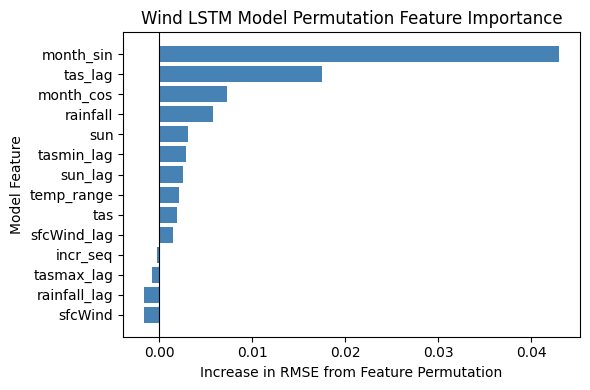

In [217]:
#plotting best performing which is LSTM
plt.figure(figsize=(6, 4))
plt.barh(wind_lstm_importance['feature'], wind_lstm_importance['importance'], color='steelblue')
plt.xlabel('Increase in RMSE from Feature Permutation')
plt.ylabel('Model Feature')
plt.title('Wind LSTM Model Permutation Feature Importance')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/content/drive/My Drive/wind_fi')
plt.show()

In [218]:
#solar pfi for each model
solar_lstm_importance = permutation_importance(solar_lstm, solar_X_test, solar_y_test, pred_features, window_size=6)
solar_gru_importance = permutation_importance(solar_gru, solar_X_test, solar_y_test, pred_features, window_size=6)
solar_xlstm_importance = permutation_importance(solar_xlstm, solar_X_test, solar_y_test, pred_features, window_size=6)

print(solar_lstm_importance)
print(solar_gru_importance)
print(solar_xlstm_importance)

         feature  importance
0      month_sin    0.043025
1      month_cos    0.023602
2     tasmin_lag    0.021435
3        tas_lag    0.013092
4     tasmax_lag    0.009804
5            sun    0.009058
6     temp_range    0.007509
7   rainfall_lag    0.003386
8        sun_lag    0.003126
9            tas    0.003073
10      rainfall    0.001711
11   sfcWind_lag    0.000613
12       sfcWind   -0.000245
13      incr_seq   -0.001138
         feature  importance
0      month_sin    0.053913
1     tasmin_lag    0.013497
2     tasmax_lag    0.012837
3        tas_lag    0.011783
4      month_cos    0.009562
5        sun_lag    0.006225
6            tas    0.005785
7   rainfall_lag    0.004607
8       rainfall    0.002869
9            sun    0.002420
10       sfcWind    0.001433
11    temp_range    0.000582
12   sfcWind_lag   -0.000522
13      incr_seq   -0.002364
         feature  importance
0      month_cos    0.056354
1        tas_lag    0.053889
2      month_sin    0.039693
3     tasmax_l

In [219]:
#hyro pfi for each model
hydro_lstm_importance = permutation_importance(hydro_lstm, hydro_X_test, hydro_y_test, pred_features, window_size=6)
hydro_gru_importance = permutation_importance(hydro_gru, hydro_X_test, hydro_y_test, pred_features, window_size=6)
hydro_xlstm_importance = permutation_importance(hydro_xlstm, hydro_X_test, hydro_y_test, pred_features, window_size=6)

print(hydro_lstm_importance)
print(hydro_gru_importance)
print(hydro_xlstm_importance)

         feature  importance
0      month_cos    0.022244
1      month_sin    0.005417
2            sun    0.003671
3       rainfall    0.003367
4     temp_range    0.003293
5        sfcWind    0.002692
6        tas_lag    0.002638
7        sun_lag    0.002321
8     tasmax_lag    0.002069
9     tasmin_lag    0.001949
10           tas    0.000589
11      incr_seq   -0.000315
12  rainfall_lag   -0.000427
13   sfcWind_lag   -0.001063
         feature  importance
0      month_cos    0.033094
1      month_sin    0.017488
2        sfcWind    0.008670
3        tas_lag    0.005322
4        sun_lag    0.004867
5            sun    0.003467
6     temp_range    0.002348
7     tasmax_lag    0.002150
8       rainfall    0.000990
9     tasmin_lag    0.000799
10   sfcWind_lag    0.000231
11      incr_seq    0.000163
12  rainfall_lag   -0.000455
13           tas   -0.000652
         feature  importance
0        tas_lag    0.026147
1      month_cos    0.025200
2     tasmin_lag    0.021381
3     tasmax_l

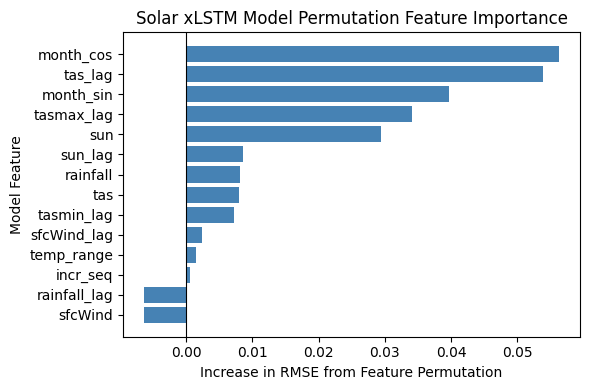

In [220]:
#plotting best model for solar which is xlstm
plt.figure(figsize=(6, 4))
plt.barh(solar_xlstm_importance['feature'], solar_xlstm_importance['importance'], color='steelblue')
plt.xlabel('Increase in RMSE from Feature Permutation')
plt.ylabel('Model Feature')
plt.title('Solar xLSTM Model Permutation Feature Importance')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/content/drive/My Drive/solar_fi')
plt.show()

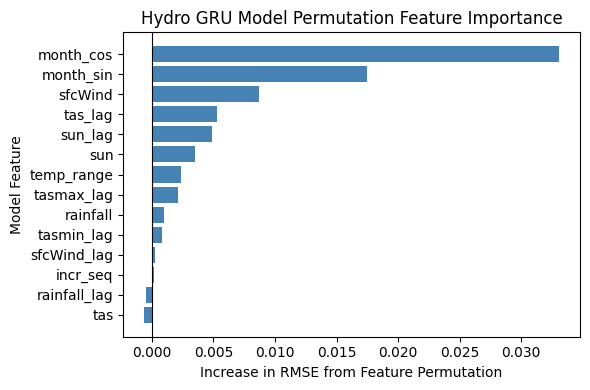

In [221]:
#plotting best model for hydro which is gru
plt.figure(figsize=(6, 4))
plt.barh(hydro_gru_importance['feature'], hydro_gru_importance['importance'], color='steelblue')
plt.xlabel('Increase in RMSE from Feature Permutation')
plt.ylabel('Model Feature')
plt.title('Hydro GRU Model Permutation Feature Importance')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/content/drive/My Drive/hydro_fi')
plt.show()

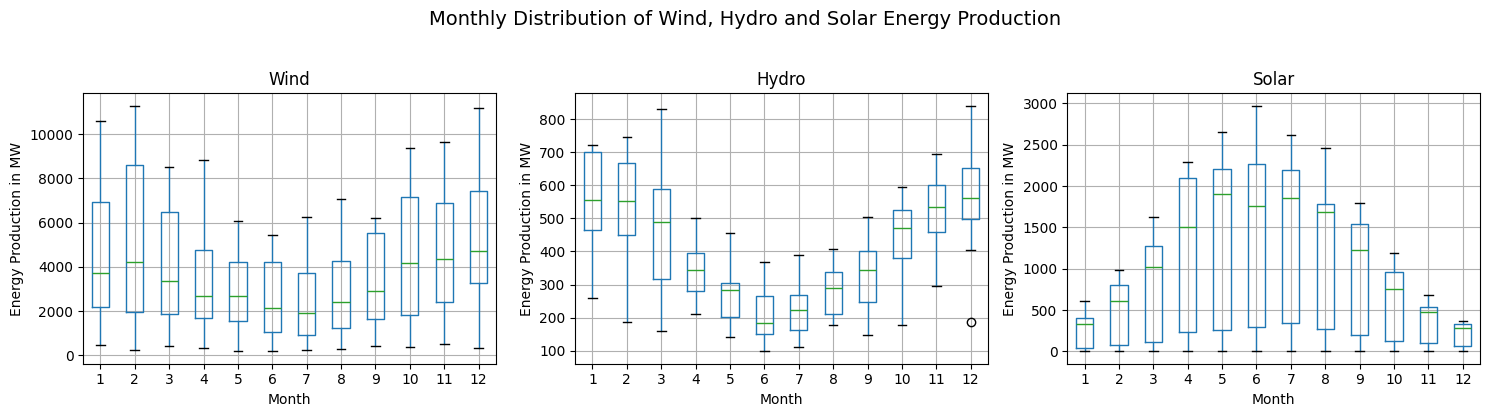

In [222]:
clean_df['month'] = pd.to_datetime(clean_df['time']).dt.month

labels = {'WIND': 'Wind', 'HYDRO': 'Hydro', 'SOLAR': 'Solar'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['WIND', 'HYDRO', 'SOLAR']):
    clean_df.boxplot(column=col, by='month', ax=ax)
    ax.set_title(labels[col])
    ax.set_xlabel('Month')
    ax.set_ylabel('Energy Production in MW')

plt.suptitle('Monthly Distribution of Wind, Hydro and Solar Energy Production', fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig('/content/drive/My Drive/monthly_boxplot.png', bbox_inches = "tight")
plt.show()

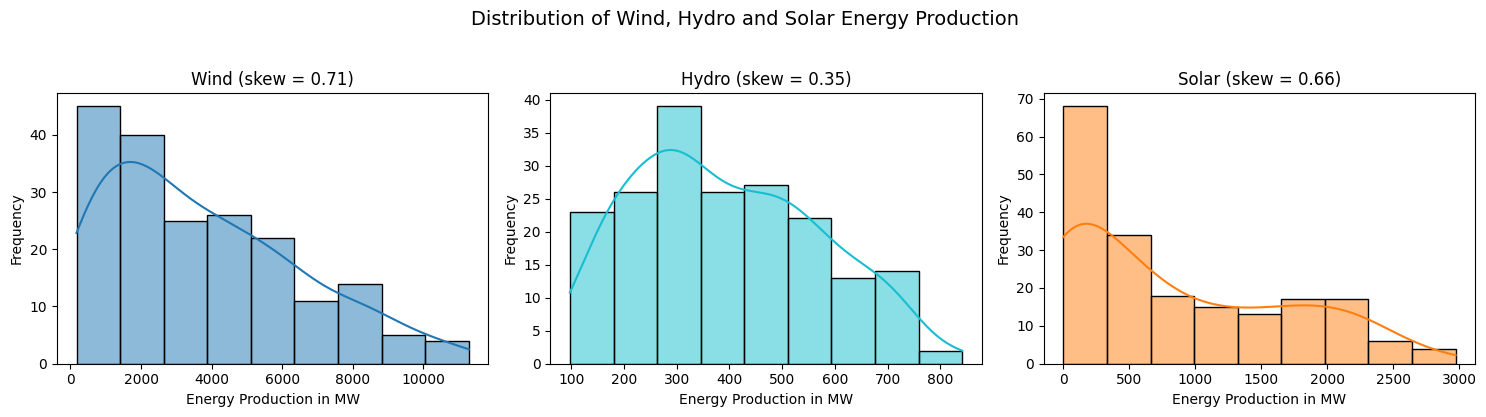

In [223]:
labels = {'WIND': 'Wind', 'HYDRO': 'Hydro', 'SOLAR': 'Solar'}
colors = {'WIND': 'tab:blue', 'HYDRO': 'tab:cyan', 'SOLAR': 'tab:orange'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['WIND', 'HYDRO', 'SOLAR']):
    sns.histplot(clean_df[col], kde=True, ax=ax, color=colors[col])
    ax.set_title(f"{labels[col]} (skew = {clean_df[col].skew():.2f})")
    ax.set_xlabel('Energy Production in MW')
    ax.set_ylabel('Frequency')

plt.suptitle('Distribution of Wind, Hydro and Solar Energy Production', fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig('/content/drive/My Drive/distribution.png', bbox_inches = "tight")
plt.show()

In [224]:
#want to scale MAPE back to original as socring it after minmax scaling made it really unstable
def scaled_score_model(model, X_test, y_test, scaler_y, window_size=6):
    X_test_seq, y_test_seq = sequence(X_test, y_test, window_size)
    X_test_t = torch.tensor(X_test_seq, dtype=torch.float32)

    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_t).numpy()

    y_true = y_test_seq

    #transform back to original units before computing MAPE
    y_true_orig = scaler_y.inverse_transform(y_true.reshape(-1, 1)).flatten()
    y_pred_orig = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()

    return {'MAE': mean_absolute_error(y_true, y_pred),'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),'MAPE': mean_absolute_percentage_error(y_true_orig, y_pred_orig)}

In [225]:
#getting scores for training and test
def get_train_test_scores(model, X_train, y_train, X_test, y_test, scaler_y, window_size=6):
    train_scores = scaled_score_model(model, X_train, y_train, scaler_y, window_size)
    test_scores = scaled_score_model(model, X_test, y_test, scaler_y, window_size)

    return {'train_MAE': train_scores['MAE'], 'test_MAE': test_scores['MAE'],'train_RMSE': train_scores['RMSE'], 'test_RMSE': test_scores['RMSE'],
        'train_R2': train_scores['R2'], 'test_R2': test_scores['R2'],
        'train_MAPE': train_scores['MAPE'], 'test_MAPE': test_scores['MAPE']}

In [226]:
#getting scores for all combinations
wind_overfit_lstm = get_train_test_scores(wind_lstm, wind_X_train, wind_y_train, wind_X_test, wind_y_test, wind_scaler_y, window_size=6)
wind_overfit_gru = get_train_test_scores(wind_gru, wind_X_train, wind_y_train, wind_X_test, wind_y_test, wind_scaler_y, window_size=6)
wind_overfit_xlstm = get_train_test_scores(wind_xlstm, wind_X_train, wind_y_train, wind_X_test, wind_y_test, wind_scaler_y, window_size=6)

solar_overfit_lstm = get_train_test_scores(solar_lstm, solar_X_train, solar_y_train, solar_X_test, solar_y_test, solar_scaler_y, window_size=6)
solar_overfit_gru = get_train_test_scores(solar_gru, solar_X_train, solar_y_train, solar_X_test, solar_y_test, solar_scaler_y, window_size=6)
solar_overfit_xlstm = get_train_test_scores(solar_xlstm, solar_X_train, solar_y_train, solar_X_test, solar_y_test, solar_scaler_y, window_size=6)

hydro_overfit_lstm = get_train_test_scores(hydro_lstm, hydro_X_train, hydro_y_train, hydro_X_test, hydro_y_test, hydro_scaler_y, window_size=6)
hydro_overfit_gru = get_train_test_scores(hydro_gru, hydro_X_train, hydro_y_train, hydro_X_test, hydro_y_test, hydro_scaler_y, window_size=6)
hydro_overfit_xlstm = get_train_test_scores(hydro_xlstm, hydro_X_train, hydro_y_train, hydro_X_test, hydro_y_test, hydro_scaler_y, window_size=6)

In [227]:
#putting all scores into combined df
all_overfit_results = []

all_overfit_results.append({**wind_overfit_lstm, 'dataset': 'WIND', 'model': 'LSTMModel'})
all_overfit_results.append({**wind_overfit_gru, 'dataset': 'WIND', 'model': 'GRUModel'})
all_overfit_results.append({**wind_overfit_xlstm, 'dataset': 'WIND', 'model': 'XLSTMModel'})

all_overfit_results.append({**solar_overfit_lstm, 'dataset': 'SOLAR', 'model': 'LSTMModel'})
all_overfit_results.append({**solar_overfit_gru, 'dataset': 'SOLAR', 'model': 'GRUModel'})
all_overfit_results.append({**solar_overfit_xlstm, 'dataset': 'SOLAR', 'model': 'XLSTMModel'})

all_overfit_results.append({**hydro_overfit_lstm, 'dataset': 'HYDRO', 'model': 'LSTMModel'})
all_overfit_results.append({**hydro_overfit_gru, 'dataset': 'HYDRO', 'model': 'GRUModel'})
all_overfit_results.append({**hydro_overfit_xlstm, 'dataset': 'HYDRO', 'model': 'XLSTMModel'})

overfit_df = pd.DataFrame(all_overfit_results)
overfit_df = overfit_df[['dataset', 'model', 'train_MAE', 'test_MAE','train_RMSE', 'test_RMSE', 'train_R2', 'test_R2','train_MAPE', 'test_MAPE']]
overfit_df

,dataset,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2,train_MAPE,test_MAPE
0,WIND,LSTMModel,0.054066,0.090788,0.071351,0.111576,0.886786,0.732476,0.298571,0.138245
1,WIND,GRUModel,0.065877,0.127155,0.087064,0.150142,0.831435,0.515578,0.403404,0.195329
2,WIND,XLSTMModel,0.058158,0.116731,0.075839,0.139847,0.872096,0.579731,0.278767,0.157170
3,SOLAR,LSTMModel,0.083371,0.140201,0.101769,0.166564,0.862263,0.735562,0.318148,0.494791
4,SOLAR,GRUModel,0.080079,0.137992,0.100480,0.166418,0.865731,0.736025,0.305562,0.496329
5,SOLAR,XLSTMModel,0.069696,0.087831,0.090237,0.107835,0.891711,0.889164,0.276305,0.266077
6,HYDRO,LSTMModel,0.122126,0.123162,0.153722,0.149154,0.589169,0.546711,0.296765,0.342855
7,HYDRO,GRUModel,0.118039,0.113368,0.147098,0.139526,0.623814,0.603342,0.266937,0.305430
8,HYDRO,XLSTMModel,0.112108,0.131025,0.139016,0.165482,0.664015,0.442035,0.272109,0.353794


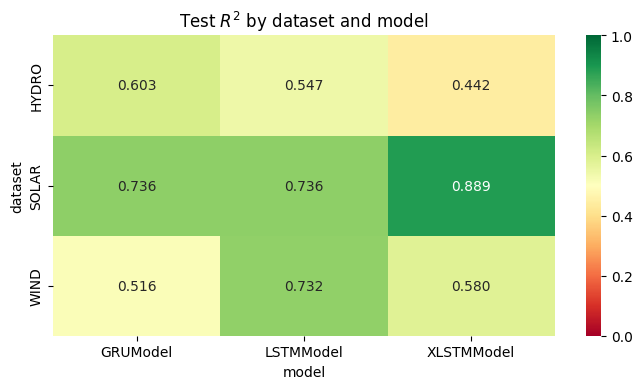

In [228]:
#reshaping results
pivot_r2 = overfit_df.pivot(index='dataset', columns='model', values='test_R2')
plt.figure(figsize=(7, 4))
#heatmap of the R2 scores to 3 decimal places.
#scaled from 0 to 1 because none of them are -ve
sns.heatmap(pivot_r2, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1)
plt.title('Test $R^2$ by dataset and model')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/test_r2') #saving to google drive
plt.show()

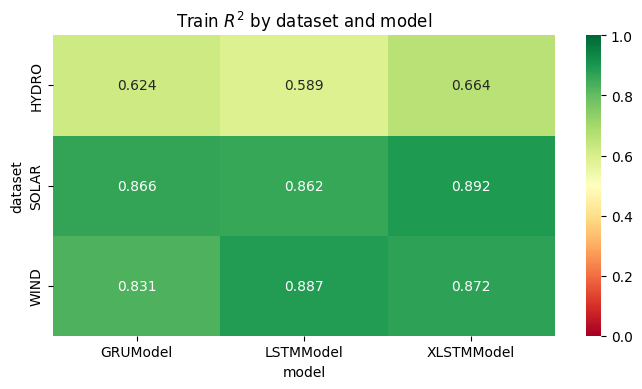

In [229]:
#reshaping results
pivot_r2 = overfit_df.pivot(index='dataset', columns='model', values='train_R2')
plt.figure(figsize=(7, 4))
#heatmap of the R2 scores to 3 decimal places.
#scaled from 0 to 1 because none of them are -ve
sns.heatmap(pivot_r2, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1)
plt.title('Train $R^2$ by dataset and model')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/train_r2') #saving to google drive
plt.show()